In [1]:
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('..')
import roi_tools


In [2]:
s_original = hs.load('../data/images/HAADF/HAADF_Buena.dm3')

left_bound = 20
right_bound = 2048 - 20
start_pixel = 200
end_pixel = 2048 - 100

s = s_original.isig[left_bound:right_bound, start_pixel:end_pixel]


In [3]:
grid_creator = roi_tools.GridCreator()
layout = grid_creator.detect_layout(s)
grid = grid_creator.process(s, layout=layout)
grid = roi_tools.equalize_patch_sizes(grid)

position_analyzer = roi_tools.PositionAnalyzer(maxfev=1000)
circular_positions, circular_parameters = position_analyzer.fit(
    grid, method='circular', return_parameters=True
)
elliptical_positions, elliptical_parameters = position_analyzer.fit(
    grid, method='elliptical', return_parameters=True
)


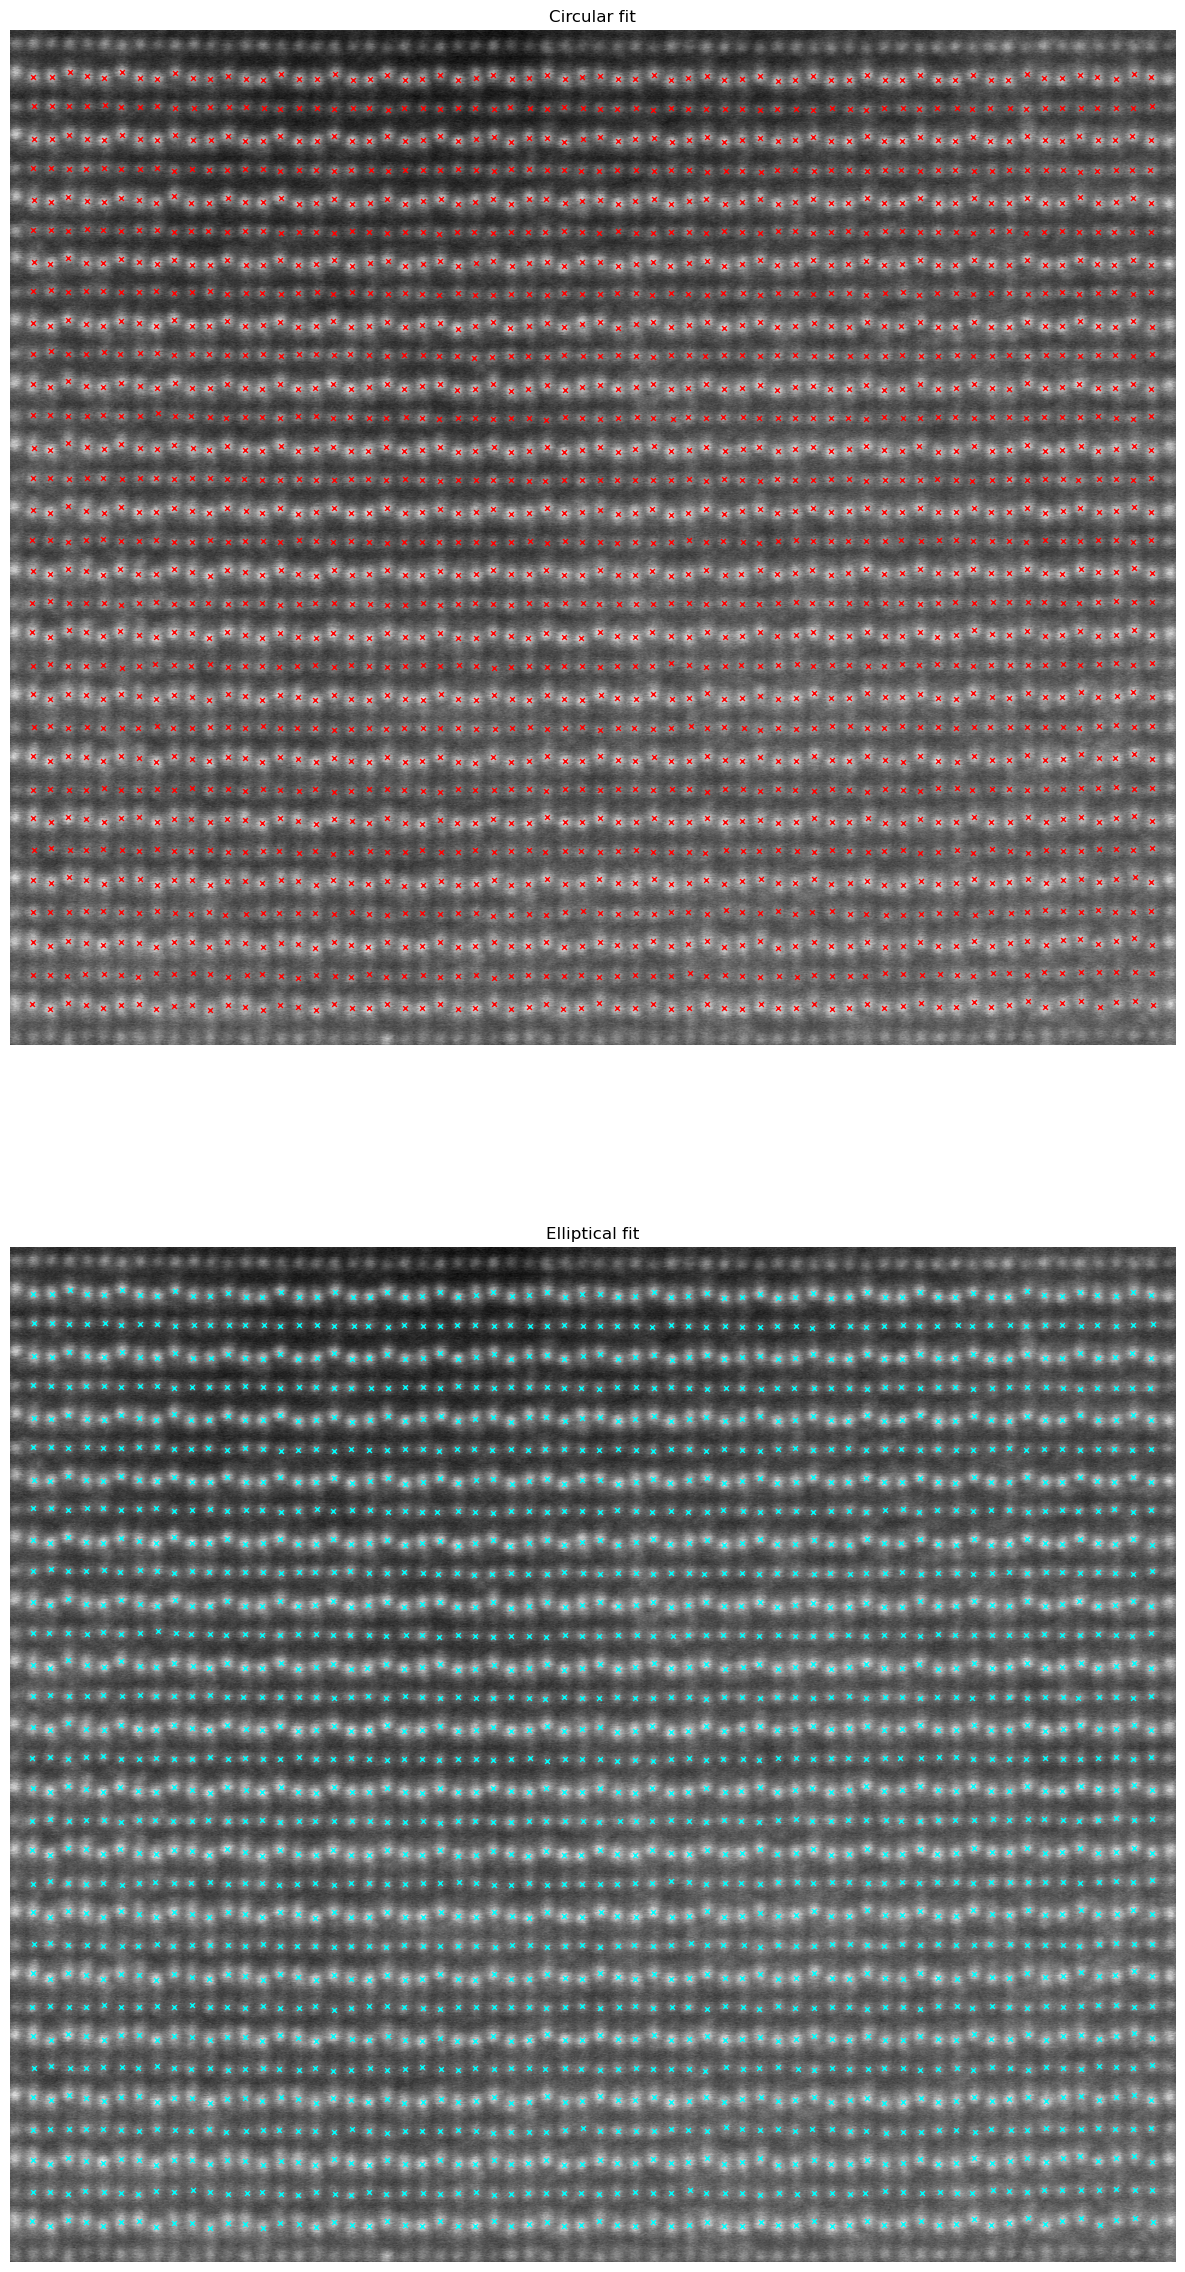

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 24))
fits = (
    ('Circular fit', circular_positions, 'red'),
    ('Elliptical fit', elliptical_positions, 'cyan'),
)

for ax, (title, positions, color) in zip(axes, fits):
    plotter = roi_tools.PatchGridPlotter(s, grid, ax=ax)
    plotter.add_positions(
        positions,
        atom_type='all',
        size=12,
        color=color,
        marker='x',
        linewidths=1.0,
        zorder=5,
    )
    ax.set_title(title)
    ax.axis('off')

fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.94, wspace=0.02)
plt.show()


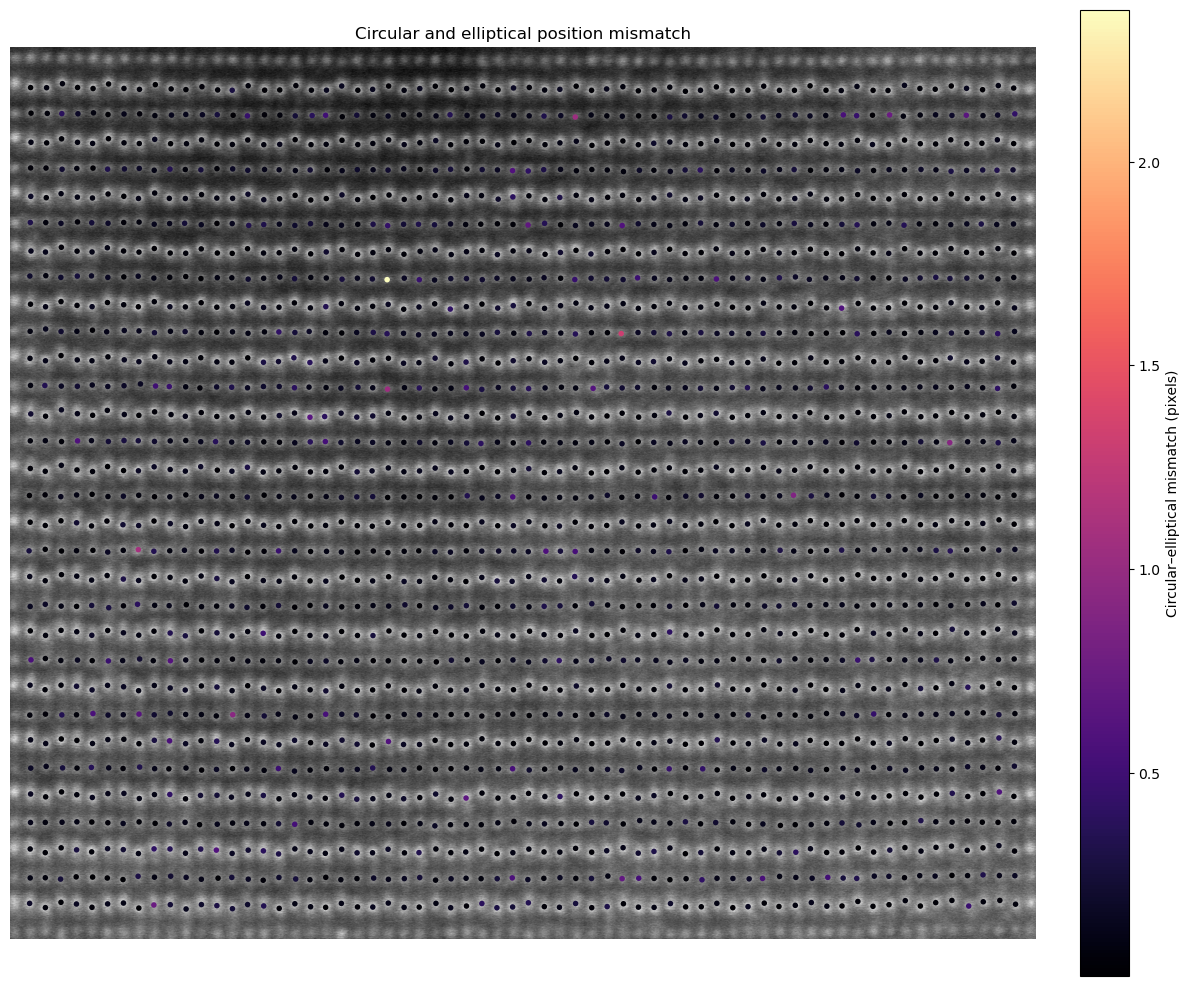

In [5]:
position_mismatch = np.linalg.norm(
    elliptical_positions - circular_positions, axis=-1
)

fig, ax = plt.subplots(figsize=(12, 10))
plotter = roi_tools.PatchGridPlotter(s, grid, ax=ax)
artist = plotter.add_positions(
    circular_positions,
    values=position_mismatch,
    atom_type='all',
    size=16,
    cmap='magma',
    marker='o',
    edgecolors='none',
    zorder=5,
)
plotter.add_colorbar(artist, label='Circular–elliptical mismatch (pixels)')
ax.set_title('Circular and elliptical position mismatch')
ax.axis('off')
fig.tight_layout()
plt.show()
